# Trajectory with STREAM2
 Stream2 trajectory and extract macrostates

Change the parameters here : 

In [1]:
# === PARAMETERS ===
input_file = "/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Matrix/p2_cll.h5ad"
patient = "P2"
output_directory = "/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Plots"
reduction='X_umap' # Reduction on which trajectory learning is based (X_umap, X_pca, X_tsne)
nb_node= 80 # Number of nodes on the trajectory graph (80)
nb_cluster= 120 # Number of cluster on the trajectory graph -> ramification (120)
trajectory_type="unsupervised" #trajectory computing unsupervised or semi-supervised based on the timepoint

In [2]:
#!pip uninstall stream2 -y
#!pip install git+https://github.com/pinellolab/STREAM2.git
# Restart the kernel
import stream2 as st2
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd
import KDEpy
from sklearn.neighbors import NearestNeighbors
import warnings
import networkx as nx
import numpy as np
#!pip3 install leidenalg
#!pip install KDEpy

/home/a.blanc-boekholt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/a.blanc-boekholt/miniconda3/lib/python3.13/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/home/a.blanc-boekholt/miniconda3/lib/python3.13/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/home/a.blanc-boekholt/miniconda3/lib/python3.13/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  return modu

In [3]:
adata = sc.read(input_file)

/home/a.blanc-boekholt/miniconda3/lib/python3.13/site-packages/anndata/_io/h5ad.py:266: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  return AnnData(**{


/home/a.blanc-boekholt/miniconda3/lib/python3.13/site-packages/anndata/_io/h5ad.py:266: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  return AnnData(**{
/home/a.blanc-boekholt/miniconda3/lib/python3.13/site-packages/stream2/plotting/_plot.py:940: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  if ann in adata.obs_keys():
/tmp/ipykernel_10661/2979099795.py:13: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata)


Found 1 components


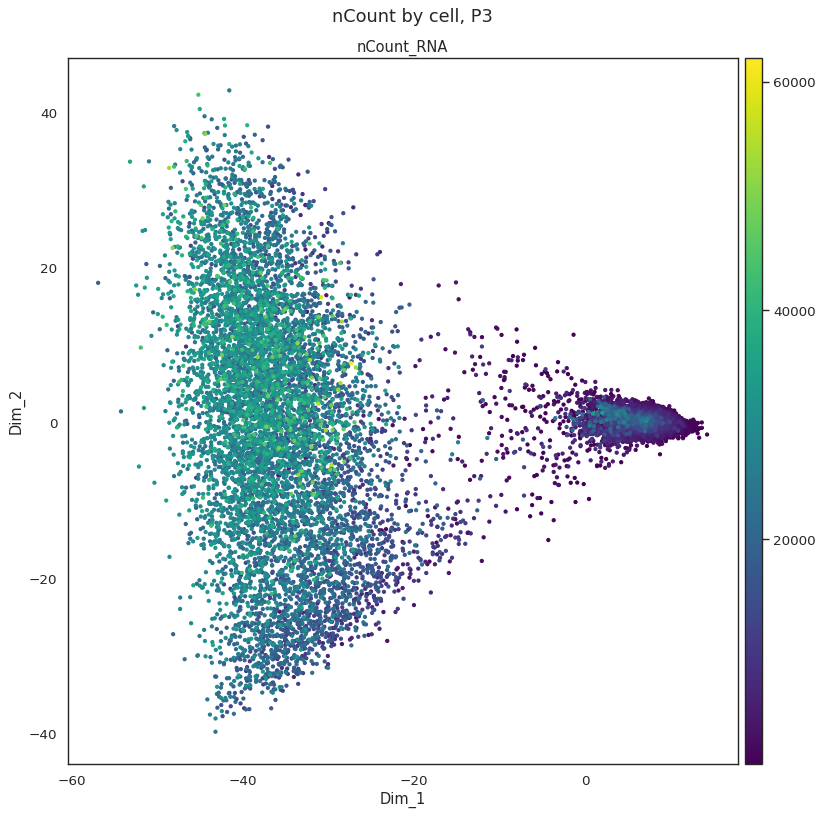

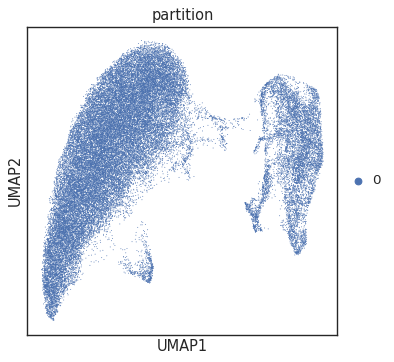

<Axes: xlabel='partition'>

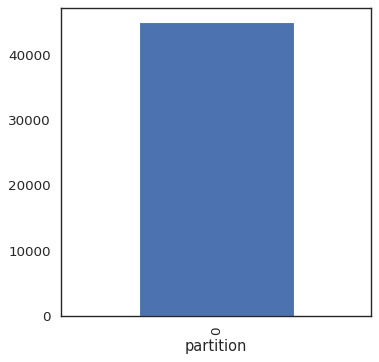

In [7]:
adata.obsm['X_dr'] = adata.obsm['X_pca']
st2.settings.set_figure_params(dpi=80,
                              style='white',
                              fig_size=[5,5],
                              rc={'image.cmap': 'viridis'})

st2.pl.dimension_reduction(adata,color=['nCount_RNA'],
                           fig_legend_ncol=2, fig_size=(10,10))
plt.suptitle(f"nCount by cell, {patient}", fontsize=16, y=1.02)
plt.savefig(f"{output_directory}/ncount_{patient}.png", dpi=300, bbox_inches='tight')
sc.pp.neighbors(adata,use_rep='X_pca',n_neighbors=10)
sc.tl.leiden(adata)
st2.tl.find_disconnected_components(adata,groups='leiden')
sc.pl.umap(adata,color='partition')
# Many are small clusters which are not adequate for trajectory inference and can be filtered out
# We keep components with more than 500 cells
adata.obs['partition'].value_counts().plot.bar()

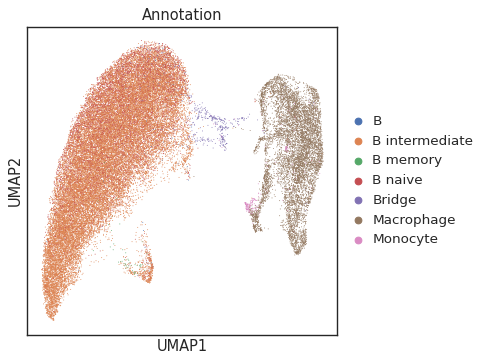

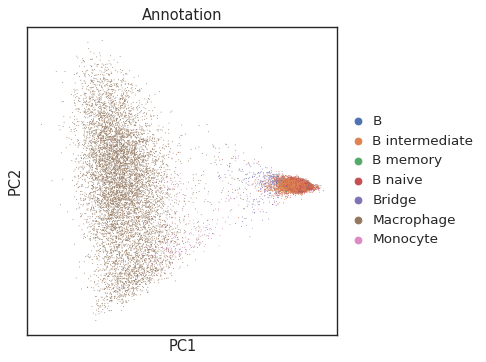

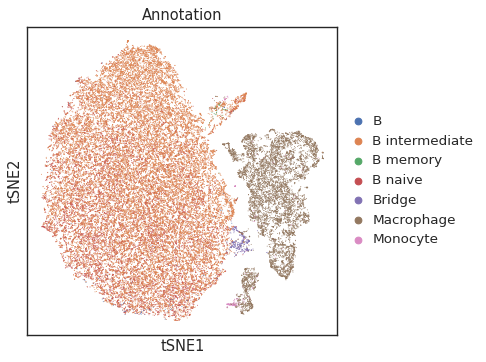

In [8]:
sc.pl.umap(adata,color=['Annotation'])
sc.pl.pca(adata,color=['Annotation'])
sc.pl.tsne(adata,color=['Annotation'])

In [9]:
if trajectory_type == "unsupervised":
    use_partition = ['0']
    dict_palette = {"D1": "#1f77b4", "D4": "#2ca02c", "D8": "#ff7f0e", "D11": "#d62728", "D14": "#9467bd"}
    
    adata.obs["timepoint"] = adata.obs["timepoint"].astype(str)
    adata.obs["timepoint"] = pd.Categorical(
        adata.obs["timepoint"],
        categories=["D1", "D4", "D8", "D11", "D14"],
        ordered=True
    )
    
    #st2.tl.get_weights(adata, bandwidth=.5, method='fft', obsm=f"{reduction}")
    st2.tl.seed_graph(adata, obsm=f"{reduction}", n_clusters=nb_cluster, use_partition=use_partition, use_weights=False)
    st2.tl.learn_graph(adata, obsm=f"{reduction}", n_nodes=nb_node, epg_alpha=0.01,epg_mu=0.2, use_partition=use_partition)
    
    # Plot 1 : graph by Annotation
    st2.pl.graph(adata, key='epg', color=['Annotation'], dict_palette=dict_palette, fig_size=(15, 10), save_fig=False)
    plt.suptitle(f"UMAP trajectory by STREAM2, {patient}", fontsize=16, y=1.02)
    plt.savefig(f"{output_directory}/graph_myel_{patient}.png", dpi=300, bbox_inches='tight')
    plt.close()
    
    # Plot 2 : graph by timepoint + edges
    fig, ax = plt.subplots(figsize=(15, 10))
    sc.pl.umap(adata, color="timepoint", palette=dict_palette, show=False, ax=ax, size=15)
    epg = adata.uns["epg"]
    nodes = epg["node_pos"]
    edges = epg["edge"]
    for edge in edges:
        p1 = nodes[edge[0]]
        p2 = nodes[edge[1]]
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color="black", linewidth=1.5, zorder=10)
    plt.suptitle(f"UMAP trajectory by STREAM2, {patient}", fontsize=16, y=1.02)
    plt.savefig(f"{output_directory}/graph_time_{patient}.png", dpi=500, bbox_inches='tight')
    plt.close()
    
    # Store graph attributes
    st2.tl._elpigraph._store_graph_attributes(adata, adata.obsm[f"{reduction}"], 'epg')
    
    # Plot 3 : graph v2 by Annotation with text
    st2.pl.graph(adata, key='epg', color=['Annotation'], show_text=True, fig_size=(8, 5), save_fig=False)
    plt.suptitle(f"UMAP trajectory by STREAM2, {patient}", fontsize=16, y=1.02)
    plt.savefig(f"{output_directory}/graph_v2_myel_{patient}.png", dpi=300, bbox_inches='tight')
    plt.close()
    
    # Plot 4 : graph by timepoint + edges + node labels
    fig, ax = plt.subplots(figsize=(15, 10))
    sc.pl.umap(adata, color="timepoint", palette=dict_palette, show=False, ax=ax, size=15)
    epg = adata.uns["epg"]
    nodes = epg["node_pos"]
    edges = epg["edge"]
    for edge in edges:
        p1 = nodes[edge[0]]
        p2 = nodes[edge[1]]
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color="black", linewidth=1.5, zorder=10)
    ax.scatter(nodes[:, 0], nodes[:, 1], c="black", s=1, zorder=11)
    for i, (x, y) in enumerate(nodes):
        ax.annotate(str(i), xy=(x, y), xytext=(5, 5), textcoords="offset points",
                    fontsize=10, fontweight="bold", color="black", zorder=12)
    plt.suptitle(f"UMAP trajectory by STREAM2, {patient}", fontsize=16, y=1.02)
    plt.savefig(f"{output_directory}/graph_time_nodes_{patient}.png", dpi=500, bbox_inches='tight')
    plt.close()

Seeding initial graph for each partition...
Learning elastic principal graph for each partition...


/home/a.blanc-boekholt/miniconda3/lib/python3.13/site-packages/stream2/plotting/_plot.py:1110: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  if ann in adata.obs_keys():
/home/a.blanc-boekholt/miniconda3/lib/python3.13/site-packages/stream2/plotting/_plot.py:1110: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  if ann in adata.obs_keys():


In [6]:
if trajectory_type == "semi-supervised":
    root_idx = 1
    k = 30

    adata.obs["day_numeric"] = adata.obs["timepoint"].astype(str).str.extract(r"D(\d+)").astype(int)
    
    knn_label_vote = adata.obs['day_numeric'].copy()
    dis, idx = NearestNeighbors(n_neighbors=k, n_jobs=30).fit(adata.obsm['X_pca']).kneighbors()
    for i, x in enumerate(np.array(adata.obs['day_numeric'])[idx]):
        unique, count = np.unique(x, return_counts=1)
        argmax = np.argmax(count)
        if count[argmax] > k / 2:
            knn_label_vote[i] = unique[argmax]
    adata.obs['knn_label_vote'] = knn_label_vote.astype(float)
    adata.obs['knn_label_vote'] = knn_label_vote

    time = adata.obs['day_numeric']
    bins = np.histogram(time, bins=3)[1]
    adata.obs['clusters'] = np.digitize(time, bins[1:], right=True)

    st2.tl.smooth_ordinal_labels(adata, root_idx, ordinal_label='clusters', obsm="X_umap")
    st2.tl.get_weights(adata, bandwidth=.5, method='fft', obsm="X_umap")
    st2.tl.seed_graph(adata, n_clusters=10, use_weights=True)
    st2.tl.learn_graph(
        adata,
        n_nodes=60, epg_alpha=0.02, epg_mu=0.1, epg_lambda=0.01,
        GPU=False, store_evolution=True, use_weights=True, use_seed=True, verbose=1,
        obsm=f"{reduction}",
        ordinal_label='knn_label_vote',
        ordinal_root_point=root_idx,
        ordinal_supervision_strength=2.5,
    )

    st2.pl.graph(adata, key='epg', color=['Annotation'], alpha=.2, size=2)
    plt.suptitle(f"UMAP trajectory by STREAM2, {patient}", fontsize=16, y=1.02)
    plt.savefig(f"{output_directory}/graph_myel_{patient}.png", dpi=300, bbox_inches='tight')
    plt.close()

In [13]:
unique_nodes = sorted(adata.obs['epg_node_id'].dropna().unique())

# Mapping node_id in a label (N1, N2...)
epg_to_label = {node: f"N{int(node)}" for node in unique_nodes}

# Macrostate column
adata.obs["segmentation"] = np.nan
adata.obs["segmentation"] = (
    adata.obs["segmentation"]
    .astype("category")
    .cat.add_categories(sorted(epg_to_label.values()))
)

# Assign the macrostate based on the nearest node
for node, label in epg_to_label.items():
    mask = adata.obs['epg_node_id'] == node
    adata.obs.loc[mask, "segmentation"] = label

print(adata.obs['segmentation'].value_counts())

segmentation
N114    889
N30     807
N97     765
N81     755
N28     743
       ... 
N53      91
N60      79
N102     75
N70      48
N23      24
Name: count, Length: 121, dtype: int64


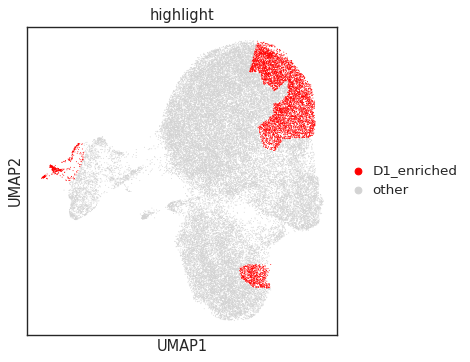

               prop_D1  n_cells  B  B intermediate  B naive  Bridge  \
segmentation                                                          
N100          0.339806      206  0             199        7       0   
N109          0.496386      415  0             400       15       0   
N114          0.446569      889  0             878       11       0   
N115          0.330882      680  0             545      135       0   
N17           0.450704      284  0             282        2       0   
N29           0.678947      380  0               4        0       1   
N39           0.369159      214  0             201       13       0   
N43           0.360000      225  0             213       12       0   
N51           0.302281      526  2             461       63       0   
N56           0.339572      374  0             331       43       0   
N61           0.401055      379  0             354       25       0   
N7            0.472318      578  0             559       19       0   
N78   

In [14]:
ct = pd.crosstab(adata.obs["segmentation"], adata.obs["timepoint"])

# days proportion (D1)
prop_D1 = ct["D1"] / ct.sum(axis=1)
# Macrostates D1-enriched (>30%) selection
selected_macrostates = prop_D1[prop_D1 > 0.30].index
# Column for UMAP
adata.obs["highlight"] = adata.obs["segmentation"].isin(selected_macrostates)
adata.obs["highlight"] = adata.obs["highlight"].map({True: "D1_enriched", False: "other"})
sc.pl.umap(adata, color="highlight", palette={"D1_enriched": "red", "other": "lightgrey"})
# Macrostates subset
subset = adata.obs.loc[
    adata.obs["segmentation"].isin(selected_macrostates), ["segmentation", "Annotation"]
].copy()
subset["segmentation"] = subset["segmentation"].astype(str)
subset["Annotation"] = subset["Annotation"].astype(str)
# Count cells per macrostates and per celltype 
annotation_counts = subset.groupby(["segmentation", "Annotation"]).size().unstack(fill_value=0)

# DataFrame
prop_D1_selected = prop_D1.loc[annotation_counts.index]
total_counts = subset["segmentation"].value_counts().reindex(annotation_counts.index)
result = pd.DataFrame({
    "prop_D1": prop_D1_selected,
    "n_cells": total_counts})
result = result.join(annotation_counts, how="left")
print(result)

Choose the initial macrostates 
Nodes 115 and 114, and only cells from D1 and annotated as B intermediate

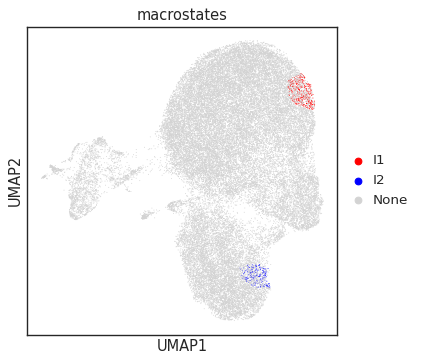

macrostates
None    41594
I1        397
I2        225
Name: count, dtype: int64

In [16]:
adata.obs["macrostates"] = "None"
# Initial_1
mask_1 = ((adata.obs["segmentation"] == "N114") & (adata.obs["timepoint"] == "D1"))
# Initial_2
mask_2 = ((adata.obs["segmentation"] == "N115") & (adata.obs["timepoint"] == "D1"))


adata.obs.loc[mask_1, "macrostates"] = "I1"
adata.obs.loc[mask_2, "macrostates"] = "I2"

sc.pl.umap( adata, color="macrostates", palette={"I1": "red", "I2": "blue", "None": "lightgrey"})

adata.obs["macrostates"].value_counts()

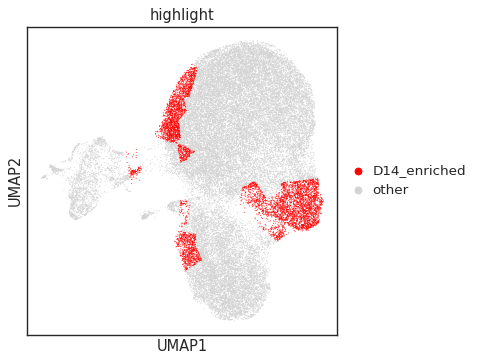

              prop_D14  n_cells   B  B intermediate  B memory  B naive  \
segmentation                                                             
N0            0.576389      144   0             126         0       18   
N106          0.562814      199   0             185         0       13   
N112          0.438596      114   0               1         0        1   
N20           0.498660      373   1             316         0       54   
N24           0.533333      390   0             372         0       18   
N28           0.481830      743   0             435         0      299   
N3            0.514218      422   0              70         0      352   
N35           0.508501      647   8             354         0      281   
N37           0.630380      395   0             369         0       25   
N40           0.437722      281   0             190         1       88   
N53           0.461538       91   0              47        16       27   
N57           0.633763      699   4   

In [17]:
# days proportion (D14)
prop_D14 = ct["D14"] / ct.sum(axis=1)
# Macrostates D1-enriched (>40%) selection
selected_macrostates = prop_D14[prop_D14 > 0.40].index
# Column for UMAP
adata.obs["highlight"] = adata.obs["segmentation"].isin(selected_macrostates)
adata.obs["highlight"] = adata.obs["highlight"].map({True: "D14_enriched", False: "other"})
sc.pl.umap(adata, color="highlight", palette={"D14_enriched": "red", "other": "lightgrey"})
# Macrostates subset
subset = adata.obs.loc[
    adata.obs["segmentation"].isin(selected_macrostates), ["segmentation", "Annotation"]
].copy()
subset["segmentation"] = subset["segmentation"].astype(str)
subset["Annotation"] = subset["Annotation"].astype(str)
# Count cells per macrostates and per celltype 
annotation_counts = subset.groupby(["segmentation", "Annotation"]).size().unstack(fill_value=0)

# DataFrame
prop_D14_selected = prop_D14.loc[annotation_counts.index]
total_counts = subset["segmentation"].value_counts().reindex(annotation_counts.index)
result = pd.DataFrame({
    "prop_D14": prop_D14_selected,
    "n_cells": total_counts})
result = result.join(annotation_counts, how="left")
print(result)

Choose the initial macrostates 
Nodes 112,3 and 57, and only cells from D14 and annotated as B intermediate

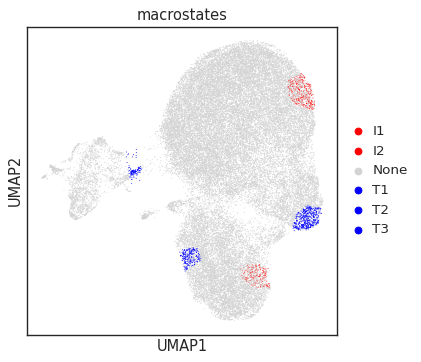

macrostates
None    40820
T3        443
I1        397
I2        225
T2        217
T1        114
Name: count, dtype: int64
timepoint
D14    50
D11    32
D8     24
D4      8
D1      0
Name: count, dtype: int64


In [18]:
adata.obs["macrostates"] = adata.obs["macrostates"].cat.add_categories(
    ["T1", "T2", "T3"])
# Terminal_1
mask_1 = ((adata.obs["segmentation"] == "N112"))
# Terminal_2
mask_2 = ((adata.obs["segmentation"] == "N3") & (adata.obs["timepoint"] == "D14"))
# Terminal_3
mask_3 = ((adata.obs["segmentation"] == "N57") & (adata.obs["timepoint"] == "D14"))

adata.obs.loc[mask_1, "macrostates"] = "T1"
adata.obs.loc[mask_2, "macrostates"] = "T2"
adata.obs.loc[mask_3, "macrostates"] = "T3"

sc.pl.umap( adata, color="macrostates", palette={"I1": "red", "I2": "red","T1": "blue", 
                                                         "T2": "blue","T3":"blue", "None": "lightgrey" })

print(adata.obs["macrostates"].value_counts())

print(adata.obs[adata.obs["macrostates"] == "T1"]["timepoint"].value_counts())

In [19]:
fig, ax = plt.subplots(figsize=(15, 10))
sc.pl.umap(adata, color="macrostates", ax=ax, show=False, size=20, palette={"I1": "red", "I2": "red","T1": "blue", 
                                                         "T2": "blue","T3":"blue", "None": "lightgrey" })
plt.suptitle(f"UMAP initial and terminal macrostates, {patient}", fontsize=16, y=1.02)
plt.savefig(f"{output_directory}/graph_macrostates_{patient}.png", dpi=500, bbox_inches='tight')  
plt.close()

In [20]:
adata_subset = adata[adata.obs["Annotation"].isin(["B intermediate", "B naive", "B memory", "B", "Bridge"])].copy()
adata_subset.write("/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Matrix/cll_macro_stream.h5ad")

## Subway plot

Found 1 components
Seeding initial graph for each partition...
Learning elastic principal graph for each partition...


Text(0.5, 1.02, 'UMAP trajectory by STREAM2, Patient 2')

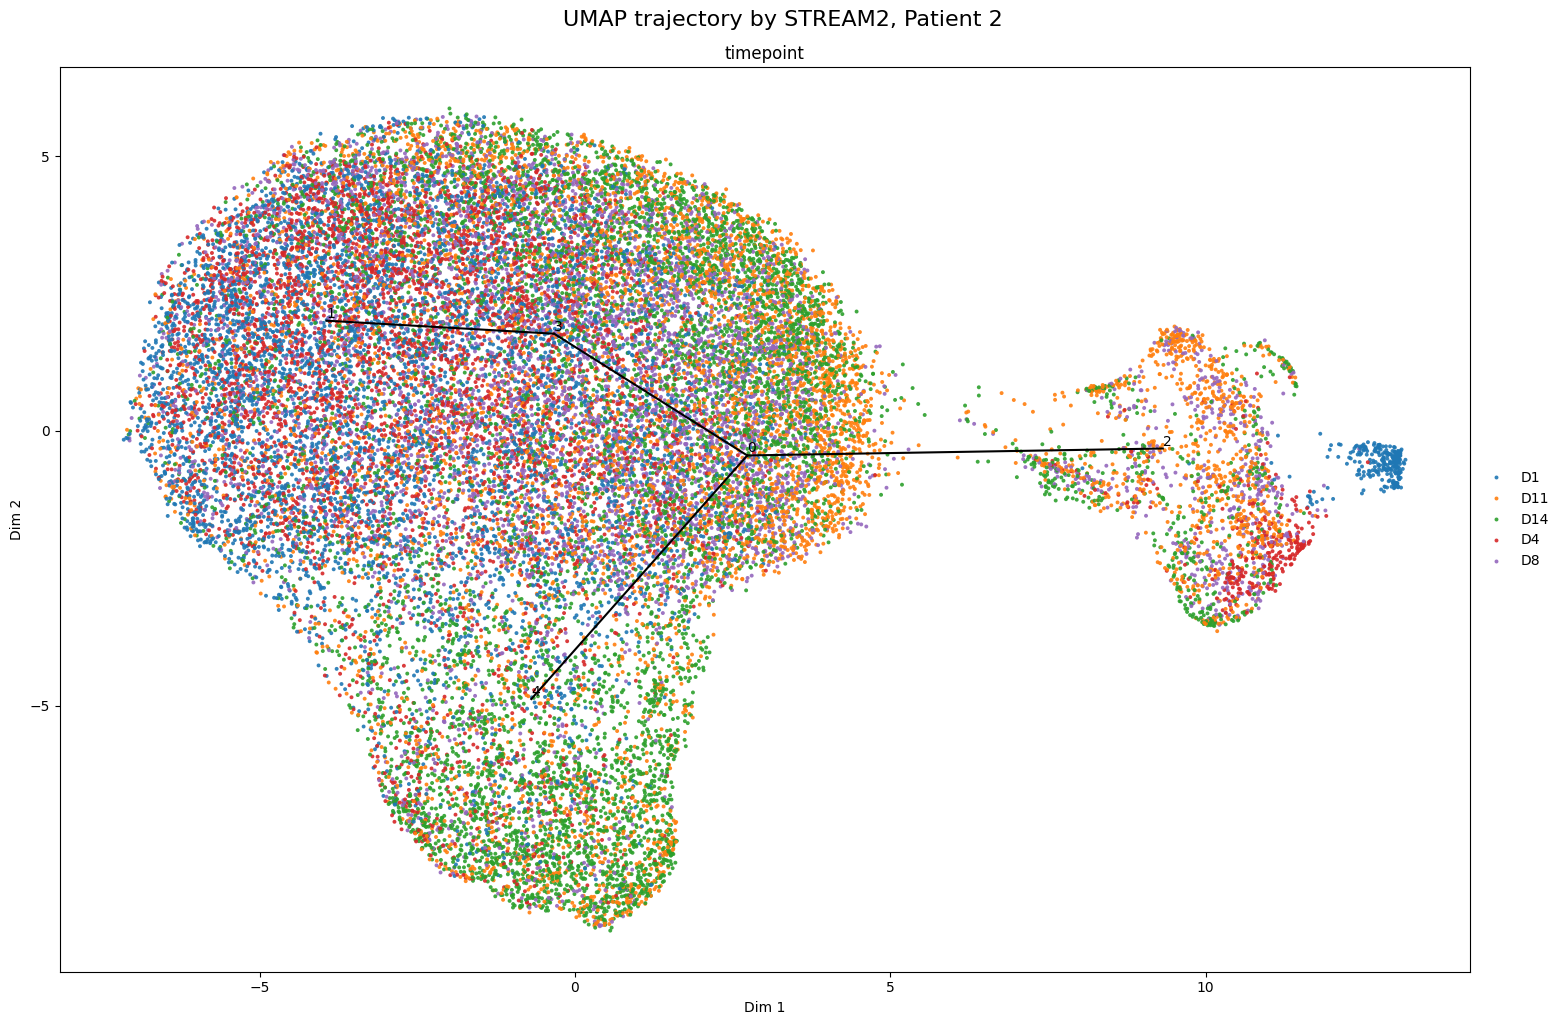

In [45]:
sc.pp.neighbors(adata,use_rep='X_pca')
sc.tl.leiden(adata)
st2.tl.find_disconnected_components(adata,groups='leiden')
use_partition=['0']
st2.tl.seed_graph(adata, obsm='X_umap', n_clusters=4,use_partition=use_partition)
st2.tl.learn_graph(adata, obsm='X_umap', n_nodes=4,epg_alpha=0.01,epg_mu=0.2,use_partition=use_partition)
st2.pl.graph(adata,key='epg',color=['timepoint'],fig_size=(15,10),save_fig=False, show_text=True)
plt.suptitle("UMAP trajectory by STREAM2, Patient 2", fontsize=16, y=1.02)
#plt.savefig("/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Plots/graph_p2.png", dpi=300, bbox_inches='tight')

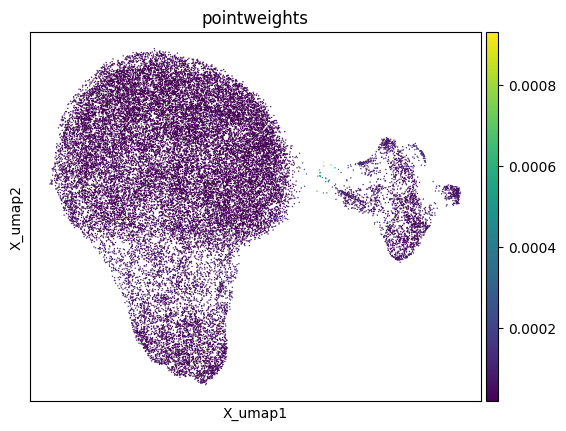

Seeding initial graph...
Clustering...
K-Means clustering ...
Calculating minimum spanning tree...


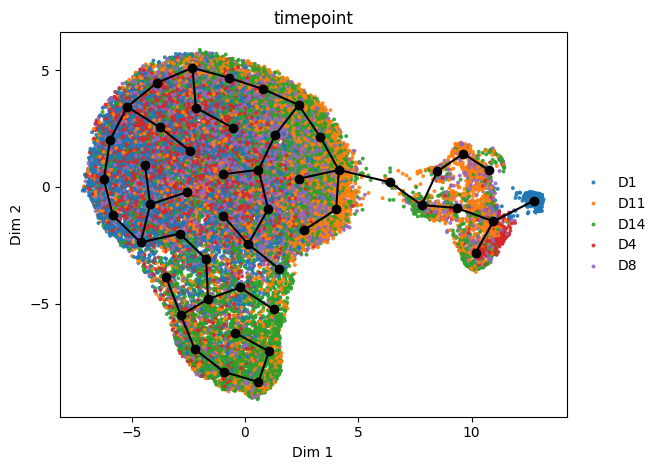

In [52]:
adata.obsm['X_dr'] = adata.obsm['X_umap']

st2.tl.get_weights(adata,bandwidth=.5,method='fft')
sc.pl.embedding(adata,basis='X_umap',color='pointweights')

st2.tl.seed_graph(adata,n_clusters=50,use_weights=True)
st2.pl.graph(adata,key='seed_epg',color=['timepoint'],show_node=1)



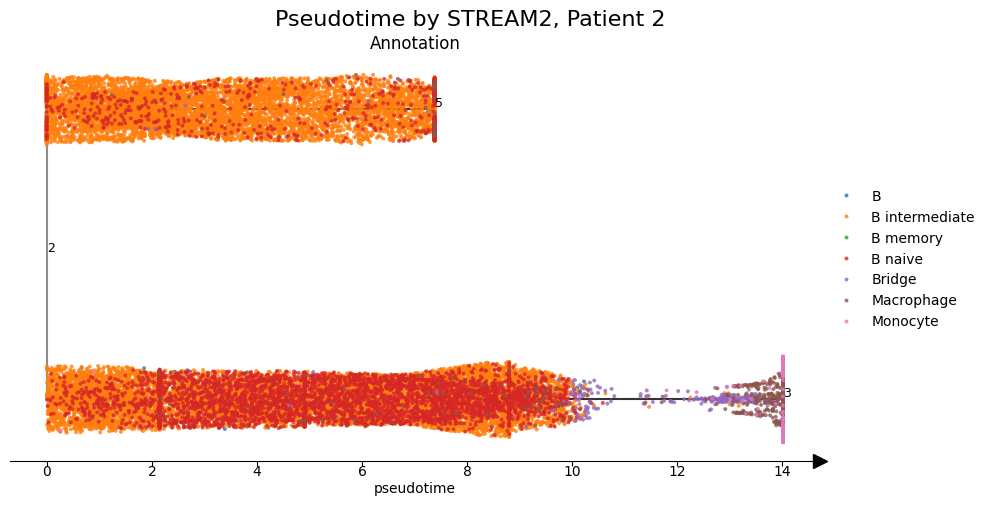

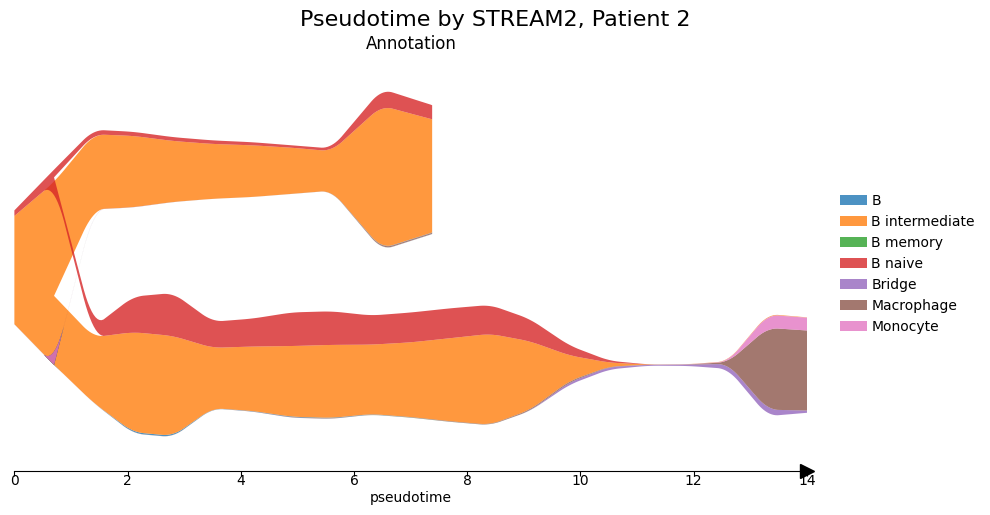

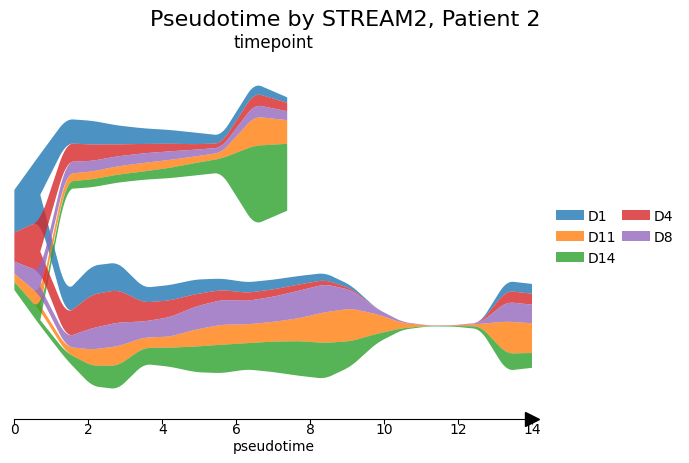

In [41]:
warnings.filterwarnings("ignore")
adata.uns['epg']['node'] = np.arange(
    adata.uns['epg']['node_pos'].shape[0]
)
st2.pl.stream_sc(adata, source=2,
                 dist_scale=0.2,
                 color=['Annotation'],
                 fig_ncol=2,fig_size=(10, 5),
                 fig_legend_ncol=1,
                 save_fig=False)
plt.suptitle("Pseudotime by STREAM2, Patient 2", fontsize=16, y=1.02)
plt.savefig("/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Plots/pseudotime_p2.png", dpi=300, bbox_inches='tight')
st2.pl.stream(adata, source=2,
                 dist_scale=1,
                 color=['Annotation'],fig_size=(10, 5),
                 fig_legend_ncol=1,
                 save_fig=False)
plt.suptitle("Pseudotime by STREAM2, Patient 2", fontsize=16, y=1.02)
plt.savefig("/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Plots/pseudotime_prop_p2.png", dpi=300, bbox_inches='tight')

st2.pl.stream(adata, source=2,
                 dist_scale=1,
                 color=['timepoint'],
                 fig_legend_ncol=2,
                 save_fig=False)
plt.suptitle("Pseudotime by STREAM2, Patient 2", fontsize=16, y=1.02)
plt.savefig("/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Plots/pseudotime_tiempnt_p2.png", dpi=300, bbox_inches='tight')

In [18]:
edges = adata.uns['stream_tree']['edge']  # array (N, 2)
nodes = adata.uns['stream_tree']['node']  # [ 0  2  7  9 13 14 18 20 22 23]

G_undirected = nx.Graph()
G_undirected.add_nodes_from(nodes)
G_undirected.add_edges_from(edges)

source = 0
G = nx.bfs_tree(G_undirected, source)

root_nodes     = [n for n in G.nodes if G.in_degree(n) == 0]
terminal_nodes = [n for n in G.nodes if G.out_degree(n) == 0]
mid_nodes      = [n for n in G.nodes if G.in_degree(n) > 0 and G.out_degree(n) > 0]

print(f"Root     : {root_nodes}")
print(f"Terminal : {terminal_nodes}")
print(f"Middle   : {mid_nodes}")

Root     : [0]
Terminal : [np.int64(13), np.int64(18), np.int64(7), np.int64(2), np.int64(22)]
Middle   : [np.int64(23), np.int64(20), np.int64(14), np.int64(9)]


In [31]:
adata.obs['macrostates'] = "None"
resultats = {}
node_positions = adata.uns['epg']['node_pos']
coords_cells = adata.obsm['X_umap']

# Build directed graph from source=0
edges = adata.uns['stream_tree']['edge']
nodes = adata.uns['stream_tree']['node']

G_undirected = nx.Graph()
G_undirected.add_nodes_from(nodes)
G_undirected.add_edges_from(edges)
G = nx.bfs_tree(G_undirected, source=0)

root_nodes     = [n for n in G.nodes if G.in_degree(n) == 0]
terminal_nodes = [n for n in G.nodes if G.out_degree(n) == 0]
mid_nodes      = [n for n in G.nodes if G.in_degree(n) > 0 and G.out_degree(n) > 0]

print(f"Root        : {root_nodes}")
print(f"Terminal    : {terminal_nodes}")
print(f"Intermediate: {mid_nodes}")

# Palette
base_color = '#FF8C42'
dict_palette = {'macrostates': {str(node): base_color for node in nodes}}
dict_palette['macrostates']['None'] = 'lightgrey'

def get_cells_near_node(node, n_cells=200, annotation_filter=None):
    """Returns n_cells closest cells to a node, with optional annotation filter."""
    coords_node = node_positions[node]
    distances = np.linalg.norm(coords_cells - coords_node, axis=1)
    if annotation_filter:
        mask = adata.obs['Annotation'] == annotation_filter
        names = adata.obs_names[mask]
        dists = distances[mask]
        return names[np.argsort(dists)[:n_cells]].tolist()
    return adata.obs_names[np.argsort(distances)[:n_cells]].tolist()

def get_cells_before_node(node, n_cells=200):
    """Returns cells in the upstream half of the edge parent → node."""
    parents = list(G.predecessors(node))
    if not parents:
        return get_cells_near_node(node, n_cells)

    parent        = parents[0]
    coords_parent = node_positions[parent]
    coords_node   = node_positions[node]

    edge_vec  = coords_node - coords_parent
    edge_len  = np.linalg.norm(edge_vec)
    edge_unit = edge_vec / edge_len

    # Project each cell onto the parent → node axis
    cell_vecs   = coords_cells - coords_parent
    projections = cell_vecs @ edge_unit

    # Upstream half: projection between 50% and 100% of edge length
    half = edge_len * 0.5
    mask = (projections > half) & (projections <= edge_len)

    dist_to_node  = np.linalg.norm(coords_cells - coords_node, axis=1)
    dist_filtered = np.where(mask, dist_to_node, np.inf)

    top_idx = np.argsort(dist_filtered)[:n_cells]
    top_idx = [i for i in top_idx if dist_filtered[i] < np.inf]

    return adata.obs_names[top_idx].tolist()

def get_cells_end_of_branch(node, n_cells=200):
    """Returns cells at the end of a terminal branch (distal half of edge)."""
    parents = list(G.predecessors(node))
    if not parents:
        return get_cells_near_node(node, n_cells)

    parent        = parents[0]
    coords_parent = node_positions[parent]
    coords_node   = node_positions[node]

    edge_vec  = coords_node - coords_parent
    edge_len  = np.linalg.norm(edge_vec)
    edge_unit = edge_vec / edge_len

    cell_vecs   = coords_cells - coords_parent
    projections = cell_vecs @ edge_unit

    # Distal half: projection > 50% of edge length
    mask = projections > (edge_len * 0.5)

    dist_to_node  = np.linalg.norm(coords_cells - coords_node, axis=1)
    dist_filtered = np.where(mask, dist_to_node, np.inf)

    top_idx = np.argsort(dist_filtered)[:n_cells]
    top_idx = [i for i in top_idx if dist_filtered[i] < np.inf]

    return adata.obs_names[top_idx].tolist()

# --- Assign macrostates ---
adata.obs['macrostates'] = "None"
resultats = {}

for node in nodes:
    if node == 2:
        # Node 2: closest Bridge-annotated cells (not end-of-branch)
        top_names = get_cells_near_node(node, 200, annotation_filter='Bridge')

    elif node in root_nodes:
        # Root node 0: 200 closest cells regardless of direction
        top_names = get_cells_near_node(node, 200)

    elif node in terminal_nodes:
        # Other terminal nodes: cells at the end of the branch
        top_names = get_cells_end_of_branch(node, 200)

    else:
        # Intermediate nodes: cells upstream of the node only
        top_names = get_cells_before_node(node, 200)

    resultats[node] = top_names
    adata.obs.loc[top_names, 'macrostates'] = str(node)

print(adata.obs['macrostates'].value_counts(dropna=False))

Root        : [0]
Terminal    : [np.int64(13), np.int64(18), np.int64(7), np.int64(2), np.int64(22)]
Intermediate: [np.int64(23), np.int64(20), np.int64(14), np.int64(9)]
macrostates
None    27560
18        200
23        200
13        200
14        200
0         200
20        200
22        200
9         200
7         200
2         200
Name: count, dtype: int64


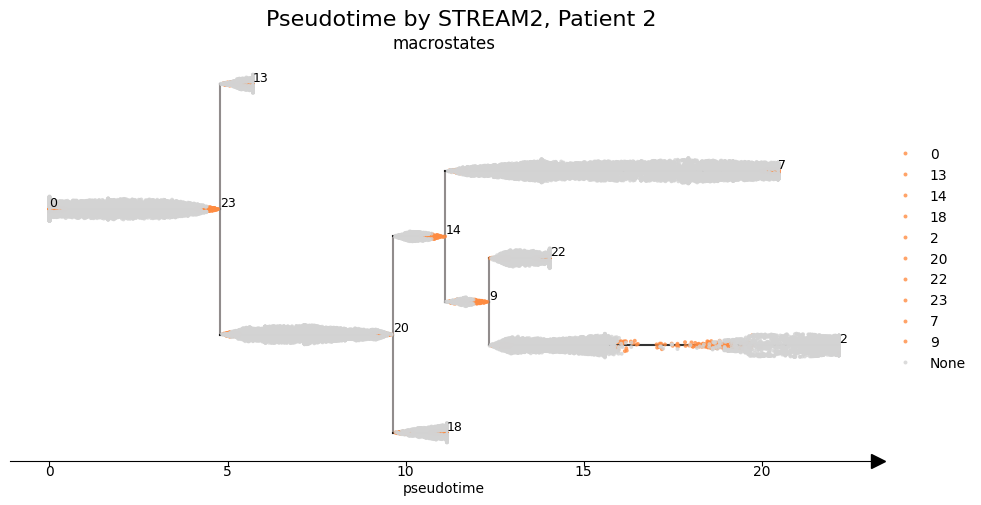

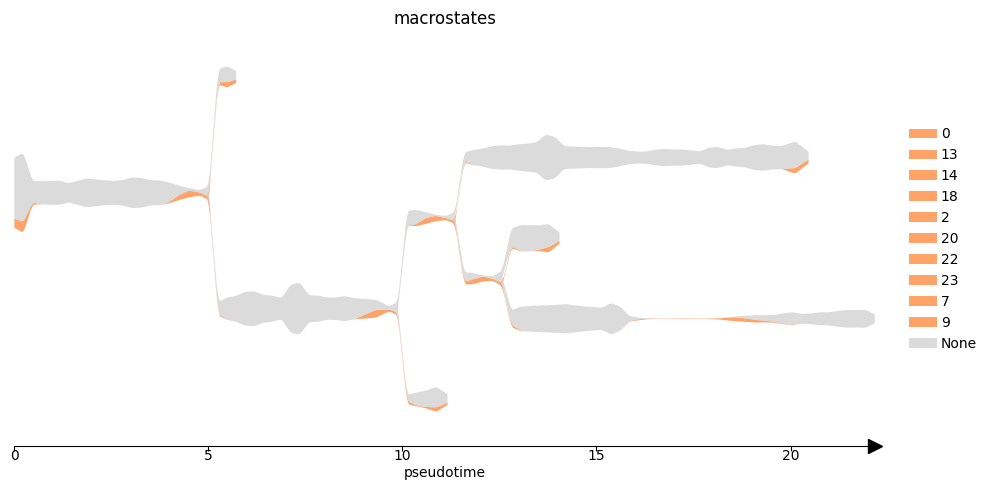

In [30]:
base_color = '#FF8C42'
dict_palette = {
    'macrostates': {str(node): base_color for node in nodes}
}
dict_palette['macrostates']['None'] = 'lightgrey'

coords_cells = adata.obsm['X_umap']

st2.pl.stream_sc(adata, source=0,
                 dist_scale=0.2,
                 color=['macrostates'],
                 fig_ncol=2,fig_size=(10, 5),dict_palette =dict_palette,
                 fig_legend_ncol=1,
                 save_fig=False)
plt.suptitle("Pseudotime by STREAM2, Patient 2", fontsize=16, y=1.02)
#plt.savefig("/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Plots/pseudotime_p2.png", dpi=300, bbox_inches='tight')

st2.pl.stream(adata, source=0,
                 dist_scale=1,
                 color=['macrostates'],fig_size=(10, 5),dict_palette =dict_palette,
                 fig_legend_ncol=1,
                 save_fig=False)

In [32]:
adata.obs["macrostates"] = adata.obs["macrostates"].apply(
    lambda x: f"S{x}" if str(x) != "None" else x)
#adata_subset = adata[adata.obs["Annotation"].isin(["B intermediate", "B naive", "B memory", "B", "Bridge","Macrophage"])].copy()
adata_subset = adata[adata.obs["Annotation"].isin(["B intermediate", "B naive", "B memory", "B", "Bridge"])].copy()
del adata_subset.uns["stream_tree"]
adata_subset.write("/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Matrix/cll_macro_stream_22.h5ad")

In [33]:
adata_subset.write("/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Matrix/cll_macro_stream_25.h5ad")

In [35]:
print(adata_subset.obs["macrostates"].unique())

['None', 'S18', 'S23', 'S13', 'S14', ..., 'S20', 'S22', 'S9', 'S7', 'S2']
Length: 11
Categories (11, object): ['None', 'S0', 'S2', 'S7', ..., 'S18', 'S20', 'S22', 'S23']
